<a href="https://colab.research.google.com/github/Savage-Soccer/Techsophy/blob/main/clip_multilingual_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Multilingual CLIP Audit — Phase 1
### Cosine Similarity Analysis Across Languages

**Languages:** English (EN), Spanish (ES), Hindi (HI), Arabic (AR), Chinese (ZH)

**Goal:** Compute cosine similarity between English anchor embeddings and all other languages.
A drop in similarity = evidence of embedding space distortion.

---
**Notebook Structure:**
1. Install & Import
2. Mount Google Drive + Load JSON queries
3. Encode all queries with CLIP
4. Save embeddings to Drive
5. Compute cosine similarities
6. Plot results

## 1. Install & Import

In [ ]:
# Install CLIP (only needs to run once per session)
!pip install git+https://github.com/openai/CLIP.git -q

  Preparing metadata (setup.py) ... done


In [ ]:
import clip
import torch
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 2. Mount Google Drive & Load Queries

**Before running:** Upload your JSON files to Google Drive at:
`My Drive/clip_audit/queries/`

Expected files:
- `queries_en.json`
- `queries_es.json`
- `queries_hi.json`
- `queries_ar.json`
- `queries_zh.json`

Each file: list of `{"id": int, "query": str}`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---- CONFIG — change paths here if needed ----
QUERIES_DIR = '/content/drive/MyDrive/clip_audit/queries'
OUTPUT_DIR  = '/content/drive/MyDrive/clip_audit/embeddings'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LANGUAGES = {
    'en': 'English',
    'es': 'Spanish',
    'hi': 'Hindi',
    'ar': 'Arabic',
    'zh': 'Chinese'
}

# Language display colors for plots
COLORS = {
    'en': '#2196F3',  # blue
    'es': '#4CAF50',  # green
    'hi': '#FF9800',  # orange
    'ar': '#E91E63',  # pink
    'zh': '#9C27B0'   # purple
}

In [ ]:
def load_queries(lang_code):
    """Load queries from JSON file for a given language code."""
    path = os.path.join(QUERIES_DIR, f'queries_{lang_code}.json')
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    # Sort by ID to ensure alignment across languages
    data = sorted(data, key=lambda x: x['id'])
    queries = [item['query'] for item in data]
    ids     = [item['id']    for item in data]
    print(f'  [{lang_code.upper()}] Loaded {len(queries)} queries')
    return ids, queries

# Load all languages
print('Loading queries...')
all_ids     = {}
all_queries = {}
for code in LANGUAGES:
    all_ids[code], all_queries[code] = load_queries(code)

# Sanity check: all languages should have same number of queries
lengths = {code: len(q) for code, q in all_queries.items()}
print(f'\nQuery counts: {lengths}')
assert len(set(lengths.values())) == 1, '❌ Query counts differ across languages! Check your JSON files.'
print('✅ All languages have matching query counts')

Loading queries...
  [EN] Loaded 18 queries
  [ES] Loaded 18 queries
  [HI] Loaded 18 queries
  [AR] Loaded 18 queries
  [ZH] Loaded 18 queries

Query counts: {'en': 18, 'es': 18, 'hi': 18, 'ar': 18, 'zh': 18}
✅ All languages have matching query counts


## 3. Load CLIP & Encode All Queries

In [ ]:
# Load CLIP model
print('Loading CLIP model...')
model, preprocess = clip.load('ViT-B/32', device=device)
model.eval()
print('✅ CLIP loaded')

Loading CLIP model...


100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 55.5MiB/s]


✅ CLIP loaded


In [ ]:
def encode_queries(queries, batch_size=32):
    """
    Encode a list of text queries using CLIP.
    Returns L2-normalised embeddings as numpy array.
    """
    all_embeddings = []

    for i in range(0, len(queries), batch_size):
        batch = queries[i:i + batch_size]
        try:
            tokens = clip.tokenize(batch, truncate=True).to(device)
        except Exception as e:
            print(f'  ⚠️  Tokenisation error at batch {i}: {e}')
            continue

        with torch.no_grad():
            embs = model.encode_text(tokens)
            # L2 normalise so cosine similarity = dot product
            embs = embs / embs.norm(dim=-1, keepdim=True)

        all_embeddings.append(embs.cpu().numpy())

    return np.vstack(all_embeddings)  # shape: (N, 512)


# Encode all languages
print('Encoding queries with CLIP...\n')
embeddings = {}
for code, name in LANGUAGES.items():
    print(f'  Encoding {name}...')
    embeddings[code] = encode_queries(all_queries[code])
    print(f'  ✅ {name}: shape {embeddings[code].shape}')

print('\n✅ All languages encoded')

Encoding queries with CLIP...

  Encoding English...
  ✅ English: shape (18, 512)
  Encoding Spanish...
  ✅ Spanish: shape (18, 512)
  Encoding Hindi...
  ✅ Hindi: shape (18, 512)
  Encoding Arabic...
  ✅ Arabic: shape (18, 512)
  Encoding Chinese...
  ✅ Chinese: shape (18, 512)

✅ All languages encoded


## 4. Save Embeddings to Google Drive
**Critical step — always save before analysis so you never recompute.**

In [ ]:
print('Saving embeddings to Drive...')
for code in LANGUAGES:
    save_path = os.path.join(OUTPUT_DIR, f'embeddings_{code}.npy')
    np.save(save_path, embeddings[code])
    print(f'  Saved: {save_path}')

print('\n✅ All embeddings saved — safe to reload anytime with np.load()')

Saving embeddings to Drive...
  Saved: /content/drive/MyDrive/clip_audit/embeddings/embeddings_en.npy
  Saved: /content/drive/MyDrive/clip_audit/embeddings/embeddings_es.npy
  Saved: /content/drive/MyDrive/clip_audit/embeddings/embeddings_hi.npy
  Saved: /content/drive/MyDrive/clip_audit/embeddings/embeddings_ar.npy
  Saved: /content/drive/MyDrive/clip_audit/embeddings/embeddings_zh.npy

✅ All embeddings saved — safe to reload anytime with np.load()


## 5. Compute Cosine Similarities

For each query ID, compute similarity between the English embedding and every other language.

Since embeddings are L2-normalised, cosine similarity = dot product.

In [ ]:
def cosine_similarity_paired(emb_a, emb_b):
    """
    Compute per-query cosine similarity between two embedding matrices.
    emb_a, emb_b: (N, D) numpy arrays, L2-normalised
    Returns: (N,) array of similarities
    """
    # dot product of paired rows = cosine similarity (since L2-normalised)
    return np.sum(emb_a * emb_b, axis=1)


# Compute similarity of each language against English anchor
print('Computing cosine similarities vs English anchor...\n')
similarities = {}
for code in LANGUAGES:
    if code == 'en':
        continue
    sims = cosine_similarity_paired(embeddings['en'], embeddings[code])
    similarities[code] = sims
    print(f'  {LANGUAGES[code]:10s} | mean: {sims.mean():.4f} | '
          f'min: {sims.min():.4f} | max: {sims.max():.4f} | std: {sims.std():.4f}')

# English self-similarity (sanity check — should be 1.0)
self_sim = cosine_similarity_paired(embeddings['en'], embeddings['en'])
print(f'\n  English self-similarity (sanity check): {self_sim.mean():.4f} (should be 1.0)')

Computing cosine similarities vs English anchor...

  Spanish    | mean: 0.8056 | min: 0.7015 | max: 0.8638 | std: 0.0433
  Hindi      | mean: 0.6530 | min: 0.5451 | max: 0.7491 | std: 0.0471
  Arabic     | mean: 0.6897 | min: 0.5799 | max: 0.7576 | std: 0.0493
  Chinese    | mean: 0.7092 | min: 0.6392 | max: 0.7854 | std: 0.0388

  English self-similarity (sanity check): 1.0000 (should be 1.0)


## 6. Visualise Results

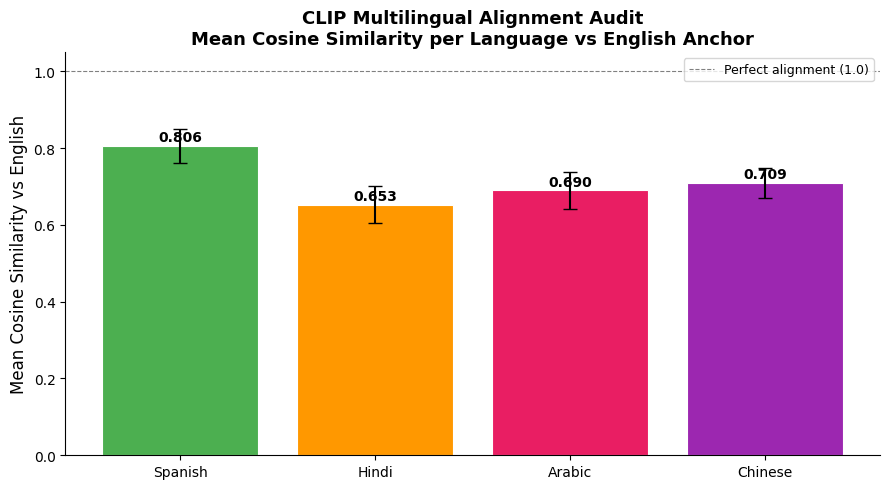

Saved: plot1_mean_similarity.png


In [ ]:
# ── Plot 1: Mean cosine similarity per language (bar chart) ──────────────────
fig, ax = plt.subplots(figsize=(9, 5))

lang_codes  = [c for c in LANGUAGES if c != 'en']
lang_names  = [LANGUAGES[c] for c in lang_codes]
mean_sims   = [similarities[c].mean() for c in lang_codes]
std_sims    = [similarities[c].std()  for c in lang_codes]
bar_colors  = [COLORS[c] for c in lang_codes]

bars = ax.bar(lang_names, mean_sims, color=bar_colors,
              yerr=std_sims, capsize=5, edgecolor='white', linewidth=0.8)

# Annotate bars with mean value
for bar, val in zip(bars, mean_sims):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Mean Cosine Similarity vs English', fontsize=12)
ax.set_title('CLIP Multilingual Alignment Audit\nMean Cosine Similarity per Language vs English Anchor',
             fontsize=13, fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Perfect alignment (1.0)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot1_mean_similarity.png'), dpi=150)
plt.show()
print('Saved: plot1_mean_similarity.png')

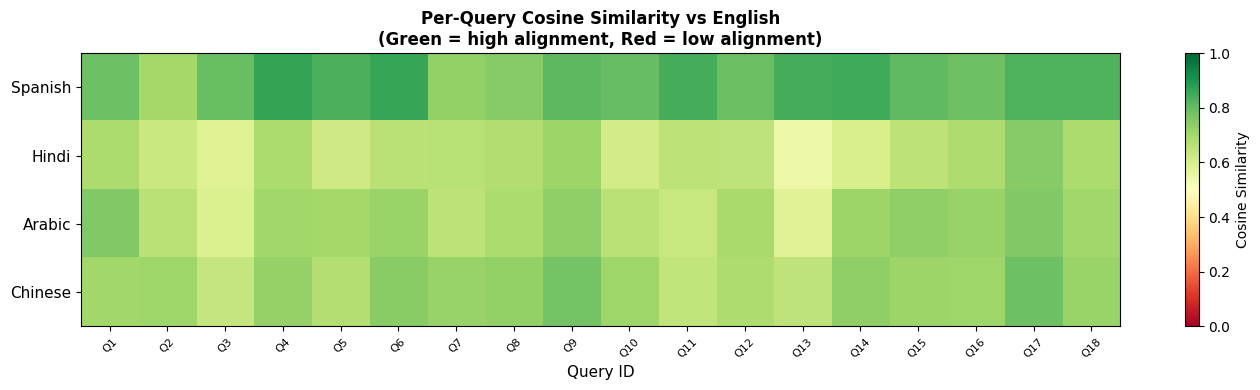

Saved: plot2_query_heatmap.png


In [ ]:
# ── Plot 2: Per-query similarity heatmap ─────────────────────────────────────
n_queries = len(all_ids['en'])
heatmap_data = np.zeros((len(lang_codes), n_queries))

for i, code in enumerate(lang_codes):
    heatmap_data[i] = similarities[code]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_yticks(range(len(lang_codes)))
ax.set_yticklabels(lang_names, fontsize=11)
ax.set_xticks(range(n_queries))
ax.set_xticklabels([f'Q{qid}' for qid in all_ids['en']], fontsize=8, rotation=45)
ax.set_xlabel('Query ID', fontsize=11)
ax.set_title('Per-Query Cosine Similarity vs English\n(Green = high alignment, Red = low alignment)',
             fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Cosine Similarity')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot2_query_heatmap.png'), dpi=150)
plt.show()
print('Saved: plot2_query_heatmap.png')

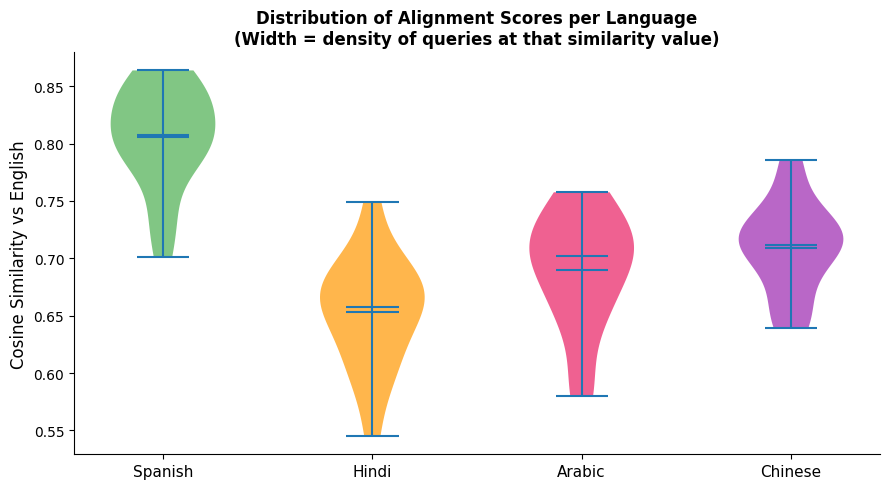

Saved: plot3_distributions.png


In [ ]:
# ── Plot 3: Distribution of similarities per language (violin plot) ───────────
fig, ax = plt.subplots(figsize=(9, 5))

data_to_plot = [similarities[c] for c in lang_codes]
parts = ax.violinplot(data_to_plot, positions=range(len(lang_codes)),
                      showmeans=True, showmedians=True)

# Colour each violin
for i, (pc, code) in enumerate(zip(parts['bodies'], lang_codes)):
    pc.set_facecolor(COLORS[code])
    pc.set_alpha(0.7)

ax.set_xticks(range(len(lang_codes)))
ax.set_xticklabels(lang_names, fontsize=11)
ax.set_ylabel('Cosine Similarity vs English', fontsize=12)
ax.set_title('Distribution of Alignment Scores per Language\n(Width = density of queries at that similarity value)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot3_distributions.png'), dpi=150)
plt.show()
print('Saved: plot3_distributions.png')

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
print('=' * 60)
print('SUMMARY: Cosine Similarity vs English Anchor')
print('=' * 60)
print(f'{"Language":<12} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 60)
for code in lang_codes:
    s = similarities[code]
    print(f'{LANGUAGES[code]:<12} {s.mean():>8.4f} {s.std():>8.4f} {s.min():>8.4f} {s.max():>8.4f}')
print('=' * 60)
print('\nNote: Lower mean = more distortion vs English embedding space')
print('Note: Higher std = inconsistent alignment across query types')

SUMMARY: Cosine Similarity vs English Anchor
Language         Mean      Std      Min      Max
------------------------------------------------------------
Spanish        0.8056   0.0433   0.7015   0.8638
Hindi          0.6530   0.0471   0.5451   0.7491
Arabic         0.6897   0.0493   0.5799   0.7576
Chinese        0.7092   0.0388   0.6392   0.7854

Note: Lower mean = more distortion vs English embedding space
Note: Higher std = inconsistent alignment across query types


## What to look for in your results

| Observation | What it means |
|---|---|
| Hindi/Arabic mean notably lower than Spanish | Script difference causes more distortion than language family |
| High std for any language | Alignment is inconsistent — some concepts transfer, others don't |
| Specific queries with low similarity across all languages | Those concepts may be culturally anchored to English |
| Spanish close to 1.0, Hindi much lower | Confirms language-induced manifold distortion hypothesis |

---





 Spanish at 0.81 makes complete sense. Latin script, heavily represented in CLIP's training data, grammatically closer to English. This is your "expected high-resource" baseline.
Hindi at 0.65 — this is your most important finding. It's the lowest. Lower than Arabic, which is also a non-Latin script. This directly supports your Language-Induced Manifold Distortion hypothesis. Devanagari script is getting hit hardest.
Arabic at 0.69 — interesting that it scores higher than Hindi despite also being a non-Latin RTL script. This suggests Arabic has better training data representation in CLIP than Hindi does. Worth noting in your paper.
Chinese at 0.71 — logographic script but scores better than both Hindi and Arabic. Likely because Chinese internet data is massive and well-represented in CLIP's training corpus.

The std values are subtle but important:
Arabic has the highest std at 0.0493. That means Arabic alignment is the most inconsistent — some concepts transfer okay, others completely fail. That inconsistency is actually a more interesting finding than just a low mean.
Chinese has the lowest std at 0.0388 — consistently mediocre rather than wildly variable.

What this means for your paper narrative:
You can now say something specific:

"Alignment degradation does not scale linearly with script difference from English. Arabic, despite its right-to-left script, outperforms Hindi, suggesting training data volume plays a confounding role alongside script complexity. Chinese, despite its logographic system, outperforms both, consistent with its large web presence in pretraining corpora."

